# 1. Setup and file reading

## 1A. Install all the packages I'm going to need


In [ ]:
! pip install biopython matplotlib numpy scipy pandas seaborn
! apt-get install -y clustalo


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 31.2 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libargtable2-0
The following NEW packages will be installed:
  clustalo libargtable2-0
0 upgraded, 2 newly installed, 0 to remove and 30 not upgraded.
Need to get 273 kB of archives.
After this operation, 694 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libargtable2-0 amd64 13-1.1 [14.1 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 clustalo amd64 1.2.4-7 [259 kB]
Fetched 273 kB in 1s (315 kB/s)
Selecting previously unselected package libargtable2-0.
(Reading database ... 126213 files and directories currently installed.)
Preparing to unpack .../libargtable2-0_13-1.1_amd64.deb ...
Unpacking libargtable2-0 (13-1.1) ...
Selecting previously unselected package clustalo.
Preparing to unpack .

## 1B. Import all the necessary libraries



In [ ]:
from Bio import SeqIO #Used to import the sequences FASTA file (.fna) and write out a translated protein FASTA file (.faa)
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

from Bio.Blast import NCBIWWW, NCBIXML

from Bio import AlignIO #Used to read and write MSA files - for ClustalOmega which I'll
from Bio.Align import AlignInfo

from Bio import pairwise2
from Bio.pairwise2 import format_alignment

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import pandas as pd
import csv

from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

/usr/local/lib/python3.11/dist-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


## 1C. Verify the version of Clustal Omega I have, just to make sure it's going to work (since the command line version of CO was deprecated)


In [ ]:
!clustalo --version

1.2.4


## 1D. Load and parse the DNA sequences from the .fna DNA FASTA file, then verify it worked

In [ ]:
# Load & parse sequences from the fasta file (already uploaded to the Colab /content folder)
sequences = list(SeqIO.parse("sequences.fna", "fasta"))

# Print info on the first 5 sequences to make sure it was parsed correctly:
for seq_record in sequences[:5]:
    print("ID:", seq_record.id) #sequence ID
    print("Length:", len(seq_record.seq)) #sequence length
    print("Sequence snippet:", seq_record.seq[:20], "...") #first 20 bases
    print("-" * 20)  #separator

ID: sparrow_myoglobin
Length: 723
Sequence snippet: TGTCAAATATCTGGAGGTAT ...
--------------------
ID: finch_myoglobin
Length: 723
Sequence snippet: TGTCAAATATCTGGAGGTAT ...
--------------------
ID: fruitfly_ribonuclease
Length: 1642
Sequence snippet: TTGTGGAAAATCATACGAGA ...
--------------------
ID: bovine_ribonuclease
Length: 2705
Sequence snippet: TCCAGGCCAGAATACTGGAG ...
--------------------
ID: frog_lactase
Length: 638
Sequence snippet: TAGAGTTTGTTGCAGGTACC ...
--------------------


## 2. Determine and analyze sequence properties

### 2A. GC Content

In [ ]:
 # Calculate the GC content of a DNA sequence.

    # Args:
        # sequence: The DNA sequence as a string.

    # Returns:
        # The GC content as a float.

def gc_content(sequence):

    g_count = sequence.count('G') # I changed this back to big G and big C because the new .fna is caps -Anne
    c_count = sequence.count('C')
    total_bases = len(sequence)
    gc_content = ((g_count + c_count) / total_bases)*100
    return gc_content

# Create lists to store sequence IDs and GC content values
sequence_ids = []
gc_contents = []

# Open the FASTA file and iterate through the sequences
# Store and print the sequence IDs and GC content values

for record in SeqIO.parse("/content/sequences.fna", "fasta"):
  sequence = str(record.seq)
  gc = gc_content(sequence)
  print(f"Sequence ID: {record.id}, GC content: {gc:.0f}")
  sequence_ids.append(record.id)
  gc_contents.append(gc)

Sequence ID: sparrow_myoglobin, GC content: 46
Sequence ID: finch_myoglobin, GC content: 45
Sequence ID: fruitfly_ribonuclease, GC content: 32
Sequence ID: bovine_ribonuclease, GC content: 50
Sequence ID: frog_lactase, GC content: 44
Sequence ID: salamander_lactase, GC content: 49


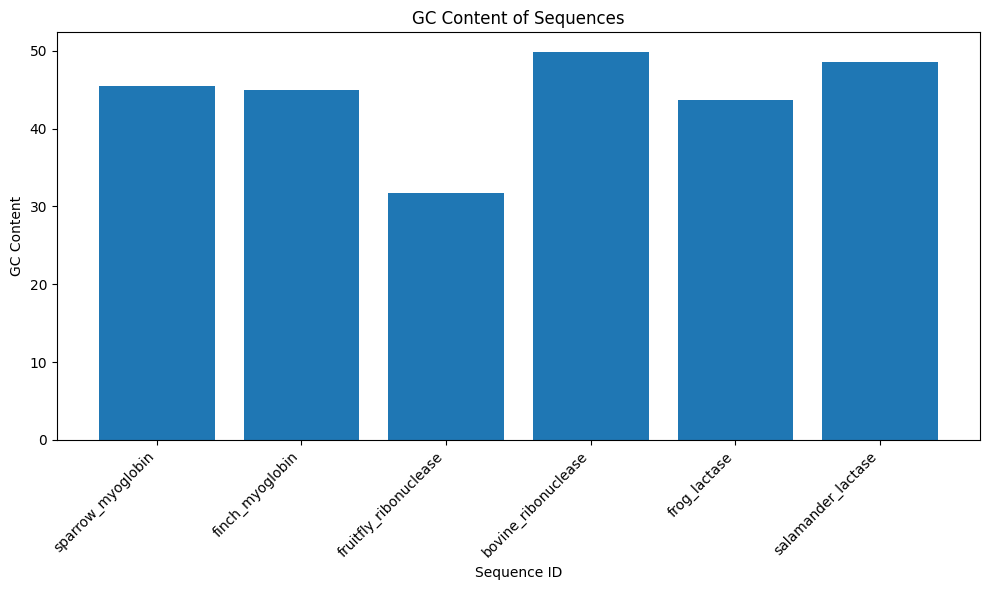

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create the bar plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.bar(sequence_ids, gc_contents)
plt.xlabel("Sequence ID")
plt.ylabel("GC Content")
plt.title("GC Content of Sequences")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

# Save the plot as a PNG image
plt.savefig("/content/gc_contents.png")

### 2B. Sequence lengths (bp)

Sequence ID: sparrow_myoglobin, Sequence Length: 723
Sequence ID: finch_myoglobin, Sequence Length: 723
Sequence ID: fruitfly_ribonuclease, Sequence Length: 1642
Sequence ID: bovine_ribonuclease, Sequence Length: 2705
Sequence ID: frog_lactase, Sequence Length: 638
Sequence ID: salamander_lactase, Sequence Length: 667


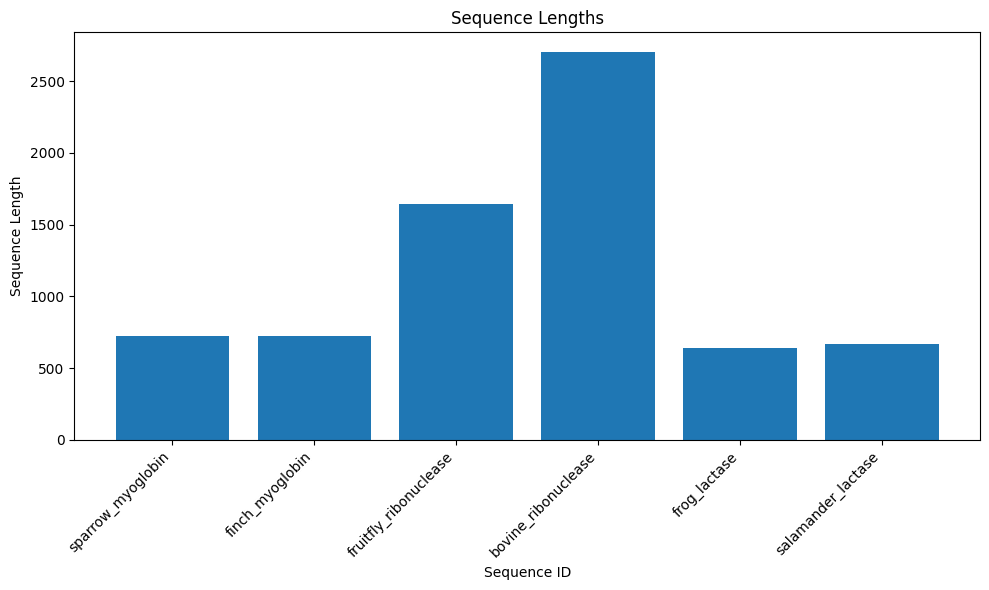

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create another list to store sequence lengths
sequence_lengths = []

# Open the FASTA file and iterate through the sequences
for record in SeqIO.parse("/content/sequences.fna", "fasta"):
    sequence = str(record.seq)

    # Calculate and store sequence length
    sequence_length = len(sequence)
    sequence_lengths.append(sequence_length)

    # Print sequence ID and length (optional)
    print(f"Sequence ID: {record.id}, Sequence Length: {sequence_length}")

# Create the bar plot
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.bar(sequence_ids, sequence_lengths)
plt.xlabel("Sequence ID")
plt.ylabel("Sequence Length")
plt.title("Sequence Lengths")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()

# Save the plot as a PNG image
plt.savefig("/content/lengths.png")

## 2C. Save GC contents and lengths in a CSV file

In [ ]:
# Assuming you have already calculated and stored the lists:
# sequence_ids, gc_contents, sequence_lengths

# Specify the CSV file name
csv_file = "/content/properties.csv"

# Open the CSV file in write mode ('w')
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)

    # Write the header row
    writer.writerow(["Sequence", "GC Content", "Length (bp)"])

    # Write data rows
    for i in range(len(sequence_ids)):
        writer.writerow([sequence_ids[i], gc_contents[i], sequence_lengths[i]])

print(f"Data saved to {csv_file}")

Data saved to /content/properties.csv


## 2D. Use Pandas to make a three-dimensional DataFrame with the sequence IDs, GC content percentages, and lengths

In [ ]:
seq_data = pd.DataFrame({ #Makes a dataframe with 3 columns: Sequence ID, Length, and GC Content
    'Sequence ID': sequence_ids,
    'Length': sequence_lengths,
    'GC Content': gc_contents
})

# Print info on the DataFrame Documentation
print("\nDataFrame Structure:")
seq_data.info()
print("\nDataFrame Head:")
print(seq_data.head())


DataFrame Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sequence ID  6 non-null      object 
 1   Length       6 non-null      int64  
 2   GC Content   6 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 276.0+ bytes

DataFrame Head:
             Sequence ID  Length  GC Content
0      sparrow_myoglobin     723   45.504841
1        finch_myoglobin     723   44.951591
2  fruitfly_ribonuclease    1642   31.668697
3    bovine_ribonuclease    2705   49.870610
4           frog_lactase     638   43.730408


## 2E. Visualize the data

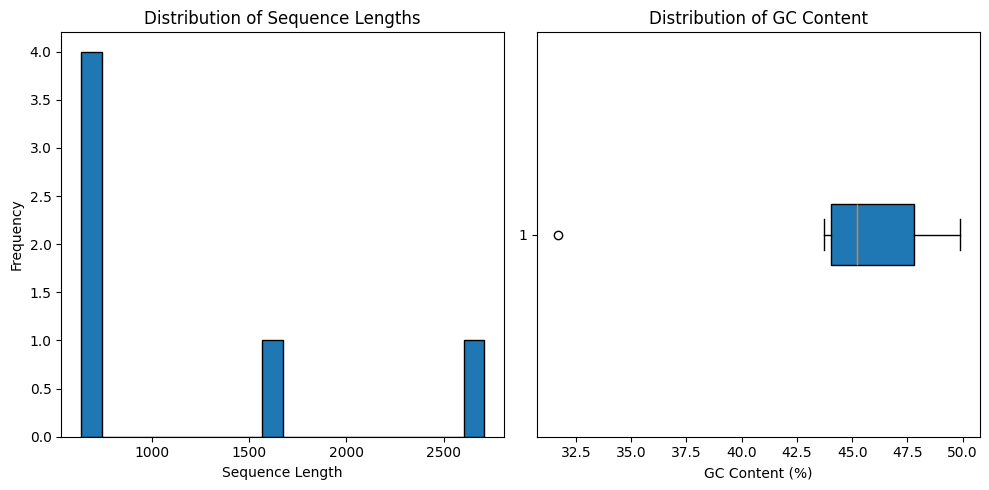

In [ ]:
# --- Exploratory Visualizations ---
plt.figure(figsize=(10, 5))

# Histogram of Sequence Lengths
plt.subplot(1, 2, 1)
plt.hist(seq_data['Length'], bins=20, edgecolor='black')
plt.title('Distribution of Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')

# Boxplot of GC Content
plt.subplot(1, 2, 2)
plt.boxplot(seq_data['GC Content'], vert=False, patch_artist=True)
plt.title('Distribution of GC Content')
plt.xlabel('GC Content (%)')

#Save plot as a png
plt.savefig("/content/distribution_lengths_GC.png")

plt.tight_layout()
plt.show()


# 3. Translate DNA sequences to protein sequences

## 3A. Translate nucleotide sequences to protein sequences and save them as a new FASTA file

In [ ]:
# Load nucleotide sequences
nucleotide_records = list(SeqIO.parse("sequences.fna", "fasta"))

# Translate sequences and create new SeqRecord objects
protein_records = []
for record in nucleotide_records:
    protein_seq = record.seq.translate()  # Translate to protein
    protein_record = SeqRecord(protein_seq, id=record.id, description="Translated sequence")
    protein_records.append(protein_record)

# Write protein sequences to a FASTA file
SeqIO.write(protein_records, "protein_sequences.fasta", "fasta")

/usr/local/lib/python3.11/dist-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


6

### 3B. Double check that the protein sequences loaded are correct and save them in an additional, temporary FASTA file

In [ ]:
# Verify correctness (print partial sequences, IDs, and lengths)
for record in protein_records[:5]:  # Print for the first 5 sequences
    print("ID:", record.id)
    print("Partial Protein Sequence:", record.seq[:20], "...")
    print("Amino Acid Length:", len(record.seq))
    print("-" * 20)


# Load protein sequences
protein_records = list(SeqIO.parse("protein_sequences.fasta", "fasta"))

# Check loaded sequences (first 3)
for record in protein_records[:3]:
    print(f"ID: {record.id}, Length: {len(record.seq)}")

# Save sequences temporarily
SeqIO.write(protein_records, "temp_proteins.fasta", "fasta")

ID: sparrow_myoglobin
Partial Protein Sequence: CQISGGMEKGRESQCLMCSE ...
Amino Acid Length: 241
--------------------
ID: finch_myoglobin
Partial Protein Sequence: CQISGGMEKGRESQCLMCSE ...
Amino Acid Length: 241
--------------------
ID: fruitfly_ribonuclease
Partial Protein Sequence: LWKIIRDSKRKIKSYVFEER ...
Amino Acid Length: 547
--------------------
ID: bovine_ribonuclease
Partial Protein Sequence: SRPEYWSG*PFPSPGIFPSQ ...
Amino Acid Length: 901
--------------------
ID: frog_lactase
Partial Protein Sequence: *SLLQVPVCGFNVPSQLVVF ...
Amino Acid Length: 212
--------------------
ID: sparrow_myoglobin, Length: 241
ID: finch_myoglobin, Length: 241
ID: fruitfly_ribonuclease, Length: 547


6

## 4. Construct and analyze sequence alignments to make evolutionary comparisons between the protein sequences

### 4A. Define the command and filepath for ClustalOmega, then use it to make a protein sequence alignment

In [ ]:
# Import the ClustalOmegaCommandline function
from Bio.Align.Applications import ClustalOmegaCommandline

# Define ClustalOmega command
clustalomega_exe = "clustalo"  # Modify infile and outfile if needed
clustal_cline = ClustalOmegaCommandline(
    clustalomega_exe,
    infile="temp_proteins.fasta",
    outfile="sequence_alignments_proteins.faa",
    verbose=True,
    auto=True
)

# Perform the MSA
stdout, stderr = clustal_cline()
print("Alignment completed.")

# Load alignment and display alignment summary
alignment = AlignIO.read("sequence_alignments_proteins.faa", "fasta")
print(alignment)
print(f"\nAlignment Length: {alignment.get_alignment_length()} positions")

/usr/local/lib/python3.11/dist-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Alignment completed.
Alignment with 6 rows and 1052 columns
--------------------------------------------...--- sparrow_myoglobin
--------------------------------------------...--- finch_myoglobin
--------------------------------------------...CVF fruitfly_ribonuclease
SRPEYWSG*PFPSPGIFPSQVSHIAGRFFTS*AARKPKNTGVGS...--- bovine_ribonuclease
--------------------------------------------...--- frog_lactase
--------------------------------------------...--- salamander_lactase

Alignment Length: 1052 positions


## 4B. Analyze the protein sequence alignment


### This code counts the number of columns in the alignment matrix (i.e. positions in each sequence), quantifies how many sequences have a certain amino acid at a certain position, calculates a conservation score for each position (0=no conservation, 1=perfect conservation), then prints the conservation scores for the first 10 positions. The conservation score is a measure of how closely related the sequences are.

In [ ]:
alignment_length = alignment.get_alignment_length()
conservation_scores = []

for i in range(alignment_length):
    col = alignment[:, i]
    most_common_aa = max(set(col), key=col.count)
    conservation = col.count(most_common_aa) / len(col)
    conservation_scores.append(conservation)

print(f"First 10 conservation scores: {conservation_scores[:10]}")

First 10 conservation scores: [0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334, 0.8333333333333334]


### 4C. Displays the alignment conservation scores as an X-Y graph (x=position, y=conservation score)

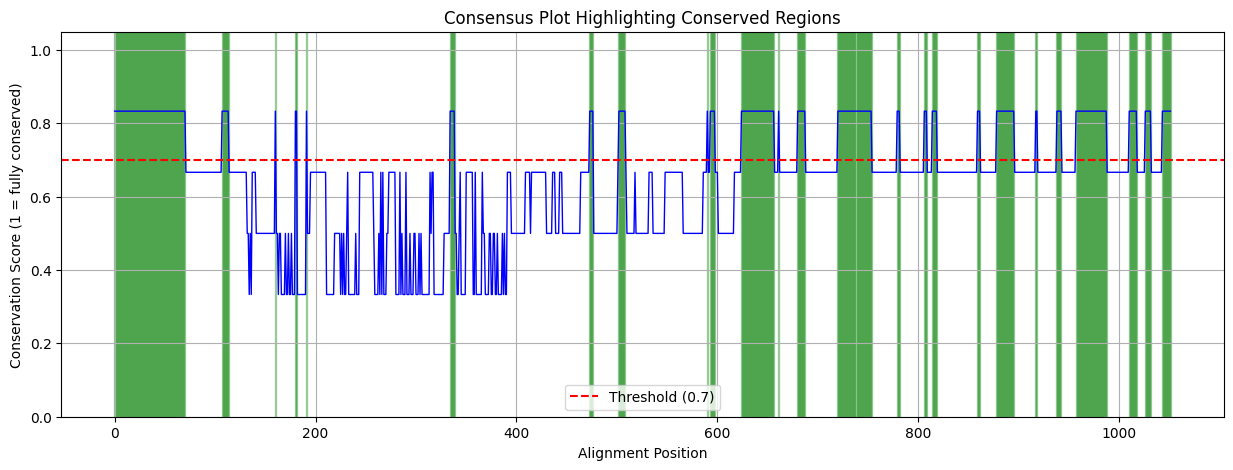

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(conservation_scores, color='blue', linewidth=1)
plt.title('Consensus Plot Highlighting Conserved Regions')
plt.xlabel('Alignment Position')
plt.ylabel('Conservation Score (1 = fully conserved)')
plt.grid(True)
plt.ylim(0, 1.05)

# Draws a line on the graph indicating the conservation threshold
threshold = 0.7
plt.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')

# Highlights conserved regions (those with at-or-above-threshold conservation scores) in green
for i, score in enumerate(conservation_scores):
    if score >= threshold:
        plt.axvspan(i - 0.5, i + 0.5, color='green', alpha=0.3)

plt.legend()

#Save figure as a PNG
plt.savefig("/content/conservation_plot.png")

#Show in notebook
plt.show()



## 4D. Perform the pairwise sequence alignment
- Load protein sequences from FASTA file
- Calculate similarity scores

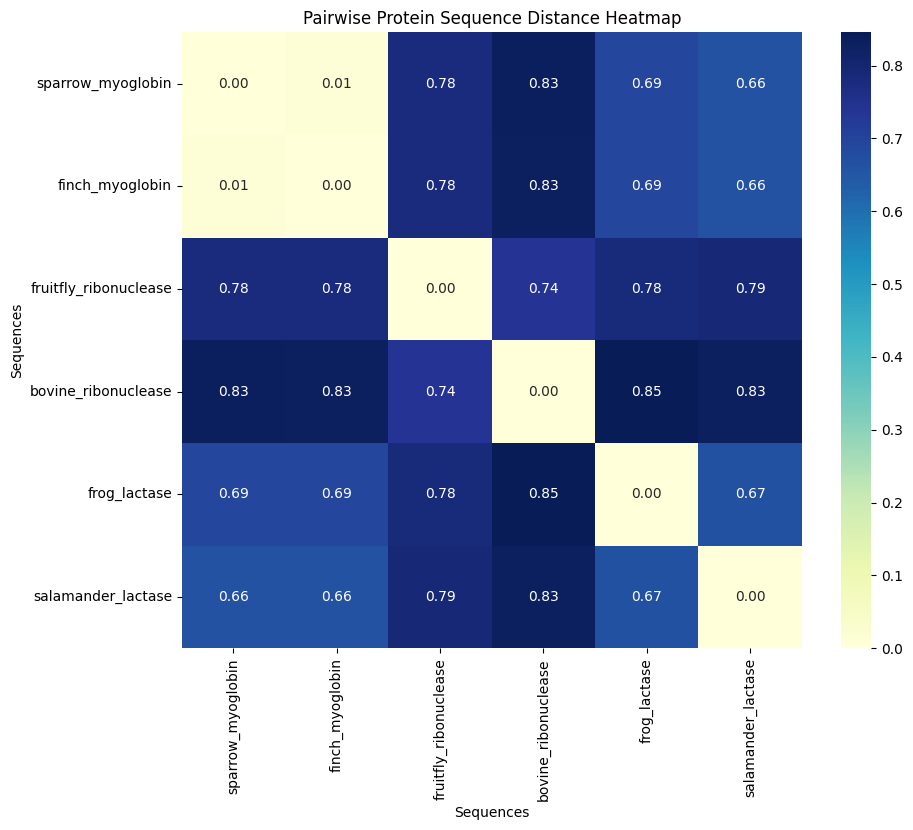

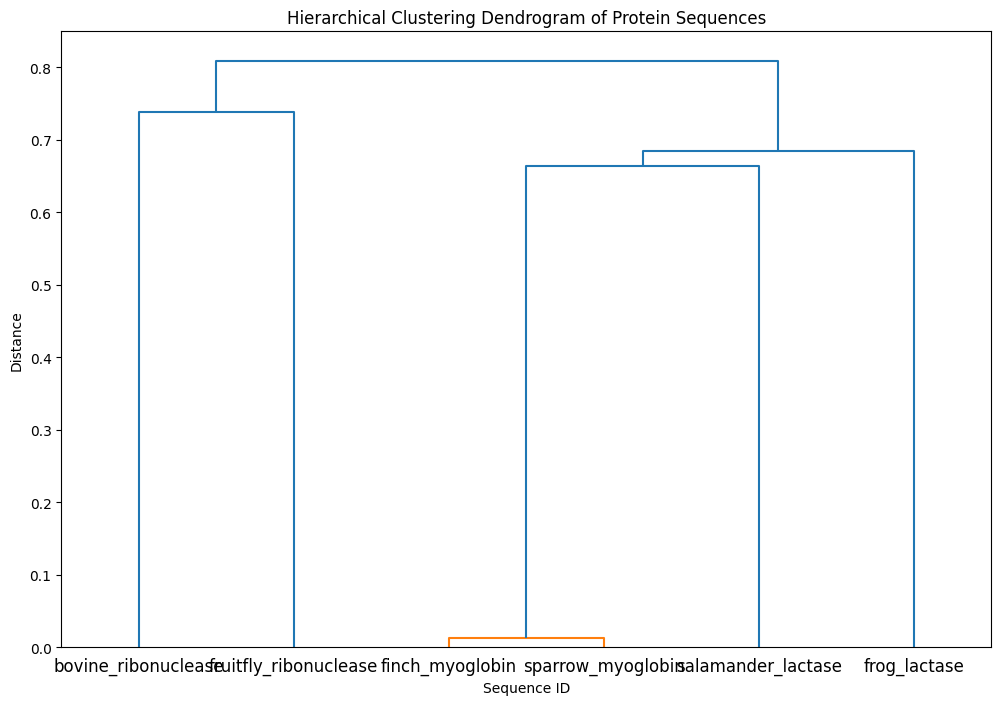

In [ ]:

# Load protein sequences from a FASTA file
sequences = list(SeqIO.parse("protein_sequences.fasta", "fasta"))
sequence_ids = [seq.id for seq in sequences]

# Set up a similarity matrix with the number of columns and rows being the number of positions in the sequence alignment (with all zeros for the actual values as placeholders))
num_seqs = len(sequences)
similarity_matrix = np.zeros((num_seqs, num_seqs))

# Calculate the alignment scores using pairwise2
for i in range(num_seqs):
    for j in range(i, num_seqs):
        alignments = pairwise2.align.globalxx(sequences[i].seq, sequences[j].seq)
        top_alignment = alignments[0]
        score = top_alignment.score
        # Normalize the score by alignment length to obtain a similarity ratio
        normalized_score = score / max(len(sequences[i]), len(sequences[j]))
        similarity_matrix[i, j] = normalized_score
        similarity_matrix[j, i] = normalized_score  # Symmetric matrix

# Transform the similarity scores into distance scores (higher similarity -> lower distance)
distance_matrix = 1 - similarity_matrix

# Perform hierarchical clustering to group similar sequences and identify outliers
linked = linkage(squareform(distance_matrix), method='average')

# Visualize the distance matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, xticklabels=sequence_ids, yticklabels=sequence_ids,
            cmap="YlGnBu", annot=True, fmt=".2f")
plt.title('Pairwise Protein Sequence Distance Heatmap')
plt.xlabel('Sequences')
plt.ylabel('Sequences')
#Save heatmap as a PNG
plt.savefig("/content/distance_matrix.png")

# Visualize the hierarchical clustering as a dendrogram
plt.figure(figsize=(12, 8))
dendrogram(linked, labels=sequence_ids, orientation='top', distance_sort='descending')
plt.title('Hierarchical Clustering Dendrogram of Protein Sequences')
plt.xlabel('Sequence ID')
plt.ylabel('Distance')
#Save dendrogram as PNG
plt.savefig("/content/hierarchical_clustering.png")

#Show figures in notebook
plt.show()

## 5. Construct and analyze phylogenetic trees to visualize evolutionary relationships between the protein structures

## 5A. Build a phylogenetic tree
- Visualizes evolutionary relationships between proteins

<Figure size 1200x800 with 0 Axes>

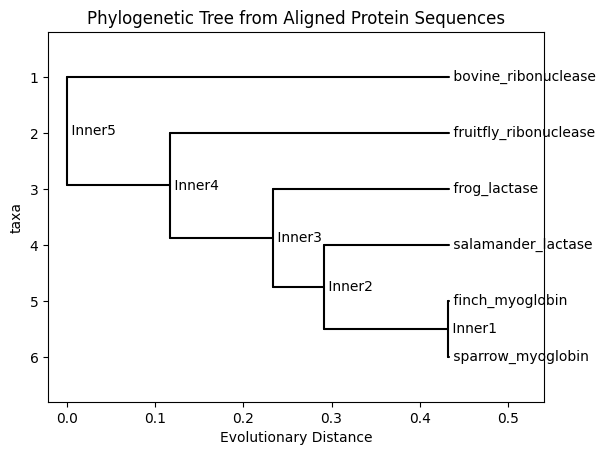

In [ ]:
# Load aligned protein sequences
alignment = AlignIO.read("sequence_alignments_proteins.faa", "fasta") # I had to change the file name from aligned_sequences.aln to sequence_alignments_proteins.faa -Anne

# Calculate the distance matrix using the 'identity' model
calculator = DistanceCalculator('identity')
distance_matrix = calculator.get_distance(alignment)

# Construct the phylogenetic tree using UPGMA (Unweighted Pair Group Method with Arithmetic Mean)
constructor = DistanceTreeConstructor()
phylo_tree = constructor.upgma(distance_matrix)

# Visualize the phylogenetic tree
plt.figure(figsize=(12, 8))
Phylo.draw(phylo_tree, do_show=False)
plt.title('Phylogenetic Tree from Aligned Protein Sequences')
plt.xlabel('Evolutionary Distance')

plt.savefig("/content/phylogenetic_tree.png")

plt.show()

## 6. Do a BLAST search of each of the protein sequences and visualize the results to get functional and organism association information

Running BLAST for: sparrow_myoglobin
Running BLAST for: finch_myoglobin
Running BLAST for: fruitfly_ribonuclease
Running BLAST for: bovine_ribonuclease


/usr/local/lib/python3.11/dist-packages/Bio/Blast/NCBIWWW.py:275: BiopythonWarning: BLAST request ZD79Z4JU013 is taking longer than 10 minutes, consider re-issuing it
  warnings.warn(


Running BLAST for: frog_lactase


/usr/local/lib/python3.11/dist-packages/Bio/Blast/NCBIWWW.py:275: BiopythonWarning: BLAST request ZD8NRHJH013 is taking longer than 10 minutes, consider re-issuing it
  warnings.warn(


Running BLAST for: salamander_lactase
              Protein_ID                                            Top_Hit  \
0      sparrow_myoglobin  hypothetical protein DV515_00009150, partial [...   
1        finch_myoglobin  hypothetical protein DV515_00009150, partial [...   
2  fruitfly_ribonuclease  ribonuclease kappa-B [Ceratitis capitata] >sp|...   
3    bovine_ribonuclease                TPA: ribonuclease A C2 [Bos taurus]   
4           frog_lactase  hypothetical protein J0S82_011404, partial [Ga...   

             Organism                                      Function  Score  \
0   Chloebia gouldiae  hypothetical protein DV515_00009150, partial  117.0   
1   Chloebia gouldiae  hypothetical protein DV515_00009150, partial  117.0   
2  Ceratitis capitata                          ribonuclease kappa-B  219.0   
3          Bos taurus                        TPA: ribonuclease A C2  916.0   
4  Galemys pyrenaicus    hypothetical protein J0S82_011404, partial  215.0   

         E-value  

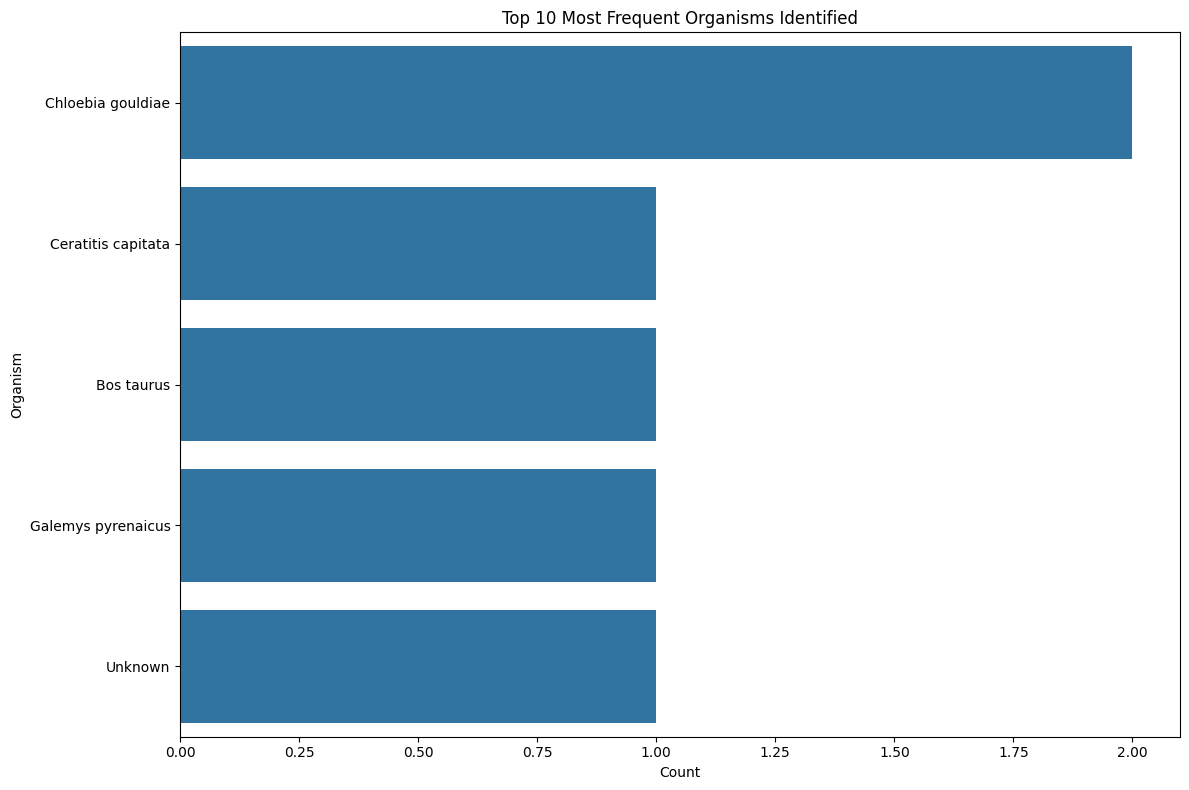

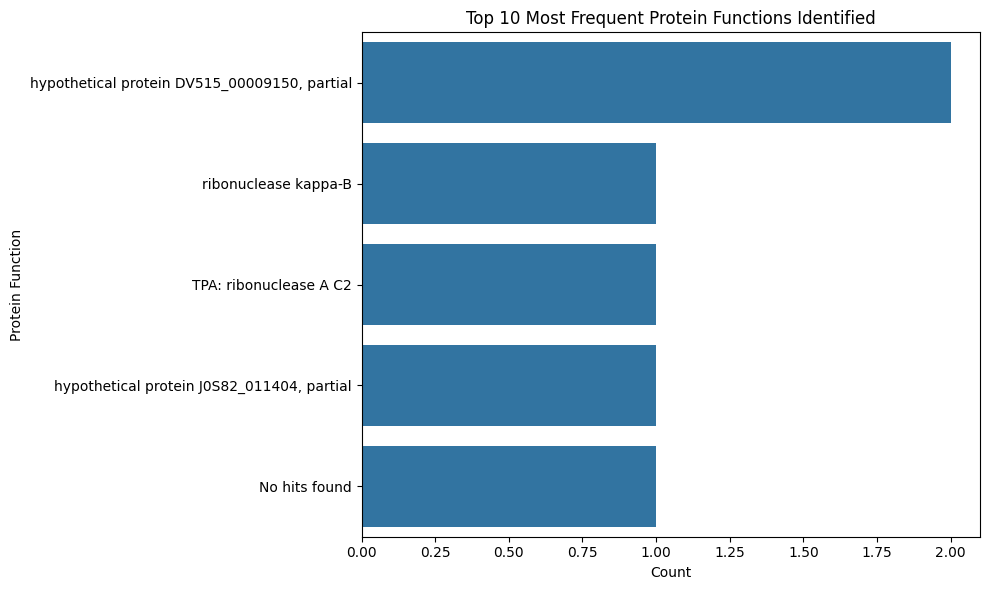

In [ ]:
# Load protein sequences
sequences = list(SeqIO.parse("protein_sequences.fasta", "fasta"))

# Perform BLAST searches against NCBI's public database
blast_results = []
for seq_record in sequences:
    print(f"Running BLAST for: {seq_record.id}")
    result_handle = NCBIWWW.qblast("blastp", "nr", seq_record.seq)
    blast_record = NCBIXML.read(result_handle)

    if blast_record.alignments:
        top_alignment = blast_record.alignments[0]
        hit_def = top_alignment.hit_def
        organism = hit_def.split('[')[-1].strip(']') if '[' in hit_def else 'Unknown'
        function_annotation = hit_def.split('[')[0].strip()
    else:
        organism = 'Unknown'
        function_annotation = 'No hits found'

    blast_results.append({
        'Protein_ID': seq_record.id,
        'Top_Hit': hit_def if blast_record.alignments else 'No hits',
        'Organism': organism,
        'Function': function_annotation,
        'Score': top_alignment.hsps[0].score if blast_record.alignments else None,
        'E-value': top_alignment.hsps[0].expect if blast_record.alignments else None
    })

# Document results clearly in a pandas DataFrame
blast_df = pd.DataFrame(blast_results)
print(blast_df.head())

# Visualize organism frequency distribution
plt.figure(figsize=(12, 8))
sns.countplot(y='Organism', data=blast_df, order=blast_df['Organism'].value_counts().index[:10])
plt.title('Top 10 Most Frequent Organisms Identified')
plt.xlabel('Count')
plt.ylabel('Organism')
plt.tight_layout()
plt.savefig("/content/organism_frequency_distribution.png")
plt.show()

# Visualize function distribution
plt.figure(figsize=(10, 6))
sns.countplot(y='Function', data=blast_df, order=blast_df['Function'].value_counts().index[:10])
plt.title('Top 10 Most Frequent Protein Functions Identified')
plt.xlabel('Count')
plt.ylabel('Protein Function')
plt.tight_layout()
plt.savefig("/content/function_distribution.png")
plt.show()
